# Session 09: MCP Connectors & X API

## Building a LangGraph Agent with GitHub MCP Tools, X API Tools, and Memory

### Learning Objectives

- **Ingest MCP servers as LangGraph tools** using `langchain-mcp-adapters` to connect to the GitHub MCP Server and use its tools programmatically
- **Wrap the X (Twitter) API as a LangChain tool** using the `@tool` decorator so a LangGraph agent can search and retrieve public posts about market sentiment
- **Build a LangGraph agent with memory** that combines MCP-sourced tools and custom tools, using `MemorySaver` for short-term conversational memory
- **Orchestrate a full workflow through the agent** — search X posts for market sentiment, generate summaries, create a GitHub repo, commit files, branch, and open a PR — all via natural language

### Overview

In this notebook, you will build a **LangGraph ReAct agent** that has access to two categories of tools:

1. **GitHub MCP tools** — loaded from the official GitHub MCP Server via `langchain-mcp-adapters`. These replace manual `git` commands with tool calls the agent can invoke.
2. **X API tools** — custom Python functions wrapped with the `@tool` decorator that call the X API v2 directly to search and retrieve posts about investment topics and market sentiment.

The agent uses **`MemorySaver`** for short-term memory so it can maintain context across multi-step workflows within a conversation thread.

---

## Breakout Room #1: Setup, Tools & Agent Construction

## Task 1: Dependencies & Environment

We need:
- `langchain-mcp-adapters` to connect to MCP servers and convert their tools into LangChain tools
- `langgraph` for our agent graph with memory
- `langchain-anthropic` for our LLM
- `requests` for the X API calls
- `nest-asyncio` for async MCP operations inside Jupyter

> NOTE: Create a `.env` file in this directory with `X_BEARER_TOKEN`, `ANTHROPIC_API_KEY`, and `GITHUB_PAT` before running.
>
> Setup references:
> - GitHub fine-grained PAT guide: [Creating a personal access token](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-fine-grained-personal-access-token)
> - X API Bearer Token setup: [X Developer Portal](https://developer.x.com/en/portal/dashboard)

In [1]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("X_BEARER_TOKEN"):
    os.environ["X_BEARER_TOKEN"] = getpass.getpass("Enter your X Bearer Token:")

if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your Anthropic API Key:")

if not os.environ.get("GITHUB_PAT"):
    os.environ["GITHUB_PAT"] = getpass.getpass("Enter your GitHub PAT:")

In [2]:
import nest_asyncio
nest_asyncio.apply()  # Required for async operations in Jupyter

In [3]:
from langchain_anthropic import ChatAnthropic

llm = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0)

# Test the connection
response = llm.invoke("Say 'MCP agent ready!' in exactly those words.")
print(response.content)

OMP: Warning #179: Function Can't set size of /tmp file failed:


MCP agent ready!


## Task 2: X API as LangChain Tools

Instead of relying on a community-built MCP server for X, we'll call the **X API v2** directly and wrap our functions with the `@tool` decorator. This makes them available to our LangGraph agent as callable tools.

This is a key architectural decision: **not everything needs to be an MCP server**. Wrapping a simple API call as a `@tool` is often simpler and more transparent.

**Documentation:**
- [LangChain Tools Conceptual Guide](https://python.langchain.com/docs/concepts/tools/)
- [X API v2 Documentation](https://developer.x.com/en/docs/x-api)

In [4]:
import requests
import json
from langchain_core.tools import tool

BEARER_TOKEN = os.environ.get("X_BEARER_TOKEN")


@tool
def search_recent_posts(query: str, max_results: int = 20) -> str:
    """Search recent X/Twitter posts using the v2 API.
    Returns posts from the last 7 days matching the query.
    Use this for keyword searches, hashtag searches, or general topic searches.

    Args:
        query: The search query (e.g., 'Stone Ridge', '#bitcoin', 'reinsurance market')
        max_results: Number of results to return (10-100, default 20)
    """
    url = "https://api.x.com/2/tweets/search/recent"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "query": query,
        "max_results": min(max(max_results, 10), 100),
        "tweet.fields": "created_at,public_metrics,author_id,text",
        "expansions": "author_id",
        "user.fields": "name,username",
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    tweets = data.get("data", [])
    if not tweets:
        return "No posts found for this query."

    result_lines = [f"Found {len(tweets)} posts:\n"]
    for t in tweets:
        metrics = t.get("public_metrics", {})
        result_lines.append(
            f"[{t.get('created_at', 'unknown')[:10]}] "
            f"{t['text'][:200]}\n"
            f"  Likes: {metrics.get('like_count', 0)} | "
            f"Retweets: {metrics.get('retweet_count', 0)}"
        )
    return "\n\n".join(result_lines)


@tool
def get_user_posts(username: str, max_results: int = 20) -> str:
    """Get recent original posts (no retweets) from a specific X/Twitter user.
    Use this when you want to see what a specific account has been posting.

    Args:
        username: The X/Twitter handle without the @ sign (e.g., 'StoneRidgeAM')
        max_results: Number of results to return (10-100, default 20)
    """
    query = f"from:{username} -is:retweet"
    return search_recent_posts.invoke({"query": query, "max_results": max_results})


x_api_tools = [search_recent_posts, get_user_posts]
print(f"Created {len(x_api_tools)} X API tools: {[t.name for t in x_api_tools]}")

Created 2 X API tools: ['search_recent_posts', 'get_user_posts']


Let's verify our X API tools work before wiring them into the agent:

In [6]:
# Quick test — search for investment-related posts
result = search_recent_posts.invoke({"query": "Stone Ridge asset management", "max_results": 10})
print(result[:500])

Found 10 posts:


[2026-03-23] @beyond_broke Correction: I checked with Grok about entities that have capped withdrawals of private credit since Dec 1st 2025: Blackrock, Morgan Stanley, Cliffwater LLC, Blue Owl Capital, Stone Ridge
  Likes: 1 | Retweets: 0

[2026-03-19] プライベートクレジット：

からの投資家離脱が消費者ローンに広がっている

消費者ローンを保有するファンドの
Stone Ridge Asset Management は
XYZおよびAFRMが発行した消費者ローンが
償還要求により明らかに圧力を受けている

Stone Ridgeが11%の償還要求に対応
XYZ、AFRMが売却されている

WSJ https://t.co/VzumUgKQEV
  Likes: 47 | Retweets: 11

[


## Task 3: Connect to GitHub MCP Server & Load Tools

Now we'll connect to the **GitHub MCP Server** — an official, GitHub-maintained MCP server that gives agents the ability to manage repositories, issues, pull requests, and more.

We use `langchain-mcp-adapters` to:
1. Connect to the remote GitHub MCP server over HTTP
2. Automatically convert all MCP tools into LangChain-compatible tools

**Documentation:**
- [langchain-mcp-adapters](https://github.com/langchain-ai/langchain-mcp-adapters)
- [GitHub MCP Server](https://github.com/github/github-mcp-server)
- [Model Context Protocol Specification](https://modelcontextprotocol.io/)

In [53]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# Connect to the GitHub MCP server using Streamable HTTP transport
mcp_client = MultiServerMCPClient(
    {
        "github": {
            "transport": "http",
            "url": "https://api.githubcopilot.com/mcp/",
            "headers": {
                "Authorization": f"Bearer {os.environ['GITHUB_PAT']}",
            },
        }
    }
)

# Load all tools from the MCP server
github_mcp_tools = await mcp_client.get_tools()

print(f"Loaded {len(github_mcp_tools)} GitHub MCP tools:\n")
for t in github_mcp_tools:
    print(f"  - {t.name}: {t.description[:80]}...")

Loaded 44 GitHub MCP tools:

  - add_comment_to_pending_review: Add review comment to the requester's latest pending pull request review. A pend...
  - add_issue_comment: Add a comment to a specific issue in a GitHub repository. Use this tool to add c...
  - add_reply_to_pull_request_comment: Add a reply to an existing pull request comment. This creates a new comment that...
  - assign_copilot_to_issue: Assign Copilot to a specific issue in a GitHub repository.

This tool can help w...
  - create_branch: Create a new branch in a GitHub repository...
  - create_or_update_file: Create or update a single file in a GitHub repository. 
If updating, you should ...
  - create_pull_request: Create a new pull request in a GitHub repository....
  - create_pull_request_with_copilot: Delegate a task to GitHub Copilot coding agent to perform in the background. The...
  - create_repository: Create a new GitHub repository in your account or specified organization...
  - delete_file: Delete a file fro

## Task 4: Build the LangGraph Agent with Memory

Now we combine **both tool sets** into a single LangGraph agent:
- **X API tools** — custom `@tool` functions for searching posts about market sentiment
- **GitHub MCP tools** — loaded from the MCP server via `langchain-mcp-adapters`

We add **`MemorySaver`** for short-term memory so the agent remembers context across the multi-step workflow.

```
\u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510     \u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510
\u2502  START   \u2502\u2500\u2500\u2500\u2500\u25b6\u2502   Agent   \u2502\u25c0\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510
\u2514\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518     \u2502  (Claude  \u2502               \u2502
                \u2502   Sonnet) \u2502               \u2502
                \u2514\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2518               \u2502
                      \u2502                     \u2502
               has tool calls?              \u2502
                /           \\               \u2502
              yes            no             \u2502
              /               \\             \u2502
    \u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510     \u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510        \u2502
    \u2502  Tool Node  \u2502     \u2502   END   \u2502        \u2502
    \u2502 (X API +    \u2502     \u2514\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518        \u2502
    \u2502  GitHub MCP)\u2502\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518
    \u2514\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518
```

In [54]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# Combine all tools: X API tools + GitHub MCP tools
all_tools = x_api_tools + github_mcp_tools
print(f"Total tools available to agent: {len(all_tools)}")
print(f"  X API tools: {[t.name for t in x_api_tools]}")
print(f"  GitHub MCP tools: {[t.name for t in github_mcp_tools]}")

Total tools available to agent: 46
  X API tools: ['search_recent_posts', 'get_user_posts']
  GitHub MCP tools: ['add_comment_to_pending_review', 'add_issue_comment', 'add_reply_to_pull_request_comment', 'assign_copilot_to_issue', 'create_branch', 'create_or_update_file', 'create_pull_request', 'create_pull_request_with_copilot', 'create_repository', 'delete_file', 'fork_repository', 'get_commit', 'get_copilot_job_status', 'get_file_contents', 'get_label', 'get_latest_release', 'get_me', 'get_release_by_tag', 'get_tag', 'get_team_members', 'get_teams', 'issue_read', 'issue_write', 'list_branches', 'list_commits', 'list_issue_types', 'list_issues', 'list_pull_requests', 'list_releases', 'list_tags', 'merge_pull_request', 'pull_request_read', 'pull_request_review_write', 'push_files', 'request_copilot_review', 'run_secret_scanning', 'search_code', 'search_issues', 'search_pull_requests', 'search_repositories', 'search_users', 'sub_issue_write', 'update_pull_request', 'update_pull_request

In [55]:
# Step 1: Define the Agent State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# Step 2: Define the system prompt
SYSTEM_PROMPT = """You are an AI investment research assistant that can search X/Twitter posts for \
market sentiment and manage GitHub repositories.

You have two categories of tools:
1. X API tools: search_recent_posts, get_user_posts \u2014 for searching and retrieving X/Twitter posts \
about investments, market sentiment, Stone Ridge, bitcoin, reinsurance, etc.
2. GitHub MCP tools: for creating repos, committing files, creating branches, opening PRs, etc.

When asked to analyze market sentiment, retrieve posts first using the X API tools, then provide \
a structured markdown summary with: Overview, Key Themes, Notable Posts, and Summary Statistics.

When asked to perform GitHub operations, use the appropriate GitHub MCP tool.
Always use the available tools when appropriate. Be concise in your responses."""


# Step 3: Bind tools to the LLM
llm_with_tools = llm.bind_tools(all_tools)


# Step 4: Define the agent node
def agent_node(state: AgentState):
    """The agent node \u2014 calls the LLM with the current conversation and available tools."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


# Step 5: Define the tool node
tool_node = ToolNode(all_tools, handle_tool_errors=True)


# Step 6: Define routing logic
def should_continue(state: AgentState) -> Literal["tools", "end"]:
    """Determine whether to call tools or end the conversation."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"


# Step 7: Build the graph
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

# Compile with MemorySaver for short-term memory across turns
checkpointer = MemorySaver()
agent = workflow.compile(checkpointer=checkpointer)

print("Agent compiled with memory and tools!")

Agent compiled with memory and tools!


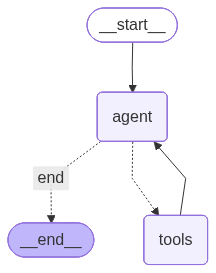

In [11]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [56]:
# Use a consistent thread_id so the agent remembers context across all tasks
config = {"configurable": {"thread_id": "mcp-investment-workflow-1"}}


async def ask_agent(user_message: str) -> str:
    """Send a message to the agent and return its final response."""
    response = await agent.ainvoke(
        {"messages": [HumanMessage(content=user_message)]},
        config,
    )
    return response["messages"][-1].content

## Task 5: Test the Agent \u2014 Search & Summarize X Posts

Let's test the agent by searching for market sentiment posts. Because we're using `MemorySaver` with a consistent `thread_id`, the agent will remember the posts it found when we ask it to summarize them.

In [13]:
# Ask the agent to fetch posts about investment topics
result = await ask_agent(
    "Search X for recent posts about bitcoin institutional adoption and reinsurance market trends."
)
print(result[:1000])

# Market Sentiment Analysis: Bitcoin Institutional Adoption & Reinsurance Trends

## Overview
The X/Twitter sentiment around bitcoin institutional adoption is overwhelmingly positive, with significant focus on major institutional players making strategic moves. The reinsurance market discussion is more limited but highlights technology as a key driver of industry evolution.

## Key Themes

### Bitcoin Institutional Adoption
- **Major Corporate Moves**: MicroStrategy's $44B Bitcoin acquisition plan is generating significant buzz
- **ETF Expansion**: Multiple mentions of new Bitcoin ETF filings, including Morgan Stanley joining the race
- **Cross-Asset Validation**: Franklin Templeton positioning XRP alongside Bitcoin and Ethereum for institutional adoption
- **Regulatory Clarity**: SEC guidance classifying Bitcoin and other major tokens as commodities, opening doors for more ETFs
- **Reserve Currency Narrative**: Growing discussion of Bitcoin as a potential reserve currency alternative


In [14]:
# Ask the agent to summarize \u2014 it remembers the posts from the previous turn!
summary = await ask_agent(
    "Now summarize those posts into a structured markdown report with sections for: "
    "Overview, Key Themes, Notable Posts, and Summary Statistics. "
    "Format it so it can be saved directly as a summary.md file."
)
print(summary)

Here's a structured markdown report based on the X/Twitter posts analysis:

```markdown
# Market Sentiment Analysis: Bitcoin Institutional Adoption & Reinsurance Market Trends

**Date:** March 24, 2026  
**Source:** X/Twitter Posts Analysis  
**Posts Analyzed:** 31 total (30 Bitcoin, 1 Reinsurance)

## Overview

Recent X/Twitter sentiment reveals overwhelmingly positive momentum around bitcoin institutional adoption, with major corporate players making significant strategic moves. The discussion centers on large-scale Bitcoin acquisitions, ETF expansions, and regulatory clarity driving institutional validation. Reinsurance market coverage is limited but highlights technology as the primary catalyst for industry transformation.

## Key Themes

### Bitcoin Institutional Adoption

**Corporate Treasury Strategies**
- MicroStrategy's proposed $44B Bitcoin acquisition generating significant attention
- Metaplanet raising $255M for aggressive Bitcoin accumulation
- European companies targetin

In [15]:
with open("summary.md", "w") as f:
    f.write(summary)

print("Summary saved to summary.md")

Summary saved to summary.md


### Question #1

How could X/Twitter sentiment analysis complement traditional investment research methods like reading investor letters?

##### Answer

*Employing Twitter for supporting sentiment analysis can give you a holistic, real-time sense of how the market feels about a certain idea. Reading investor letters can tell you how the firm is doing, through the eyes of an executive but, using Twitter for supporting analysis can tell you how everyone else in the world is feeling about a particular financial topic. Users on Twitter tend to be more unfiltered, and therefor more likely to give a realistic, if not harsh, view of how your company, or a given asset class, is doing. You can employ the wisdom of crowds in deriving a broad market sentiment as it relates to your particular field*

### Activity #1

Extend the agent with a **new custom X API tool** and verify it works end-to-end.

1. **Create a new `@tool` function** called `get_user_profile` that retrieves a user's public profile information using the X API v2 [`GET /2/users/by/username/:username`](https://developer.x.com/en/docs/x-api/users/lookup/api-reference/get-users-by-username-username) endpoint.

2. **Rebuild the agent** with the updated tool set.

3. **Test it** by asking the agent to retrieve the profile of a financial thought leader and compare it with their posts.

> HINT: The X API v2 user lookup endpoint uses the same Bearer Token authentication. You'll need `user.fields=description,public_metrics,created_at` in your request params.

In [24]:
import requests
import json
from langchain_core.tools import tool

BEARER_TOKEN = os.environ.get("X_BEARER_TOKEN")

# ----------------------------------------------
#  1) define tool for getting Twitter user info
# ----------------------------------------------
@tool
def get_user_profile(username: str) -> str:
    """
    Get profile information for a particular Twitter user
    """
    url = f"https://api.x.com/2/users/by/username/{username}"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "user.fields": "description,public_metrics,created_at",
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    user_info = data.get("data", [])
    if not user_info:
        return f"No info found for: {username}"

    return user_info


# ---------------------------------------------------------------
#  2) Add new Twitter tool to existing tool set for agentic graph
# ---------------------------------------------------------------
SYSTEM_PROMPT = """You are an AI investment research assistant that can search X/Twitter posts for \
market sentiment and manage GitHub repositories.

You have two categories of tools:
1. X API tools: search_recent_posts, get_user_posts and get_user_profile for searching and retrieving X/Twitter posts \
about users and investments, market sentiment, Stone Ridge, bitcoin, reinsurance, etc.
2. GitHub MCP tools: for creating repos, committing files, creating branches, opening PRs, etc.

When asked to analyze market sentiment, retrieve posts first using the X API tools, then provide \
a structured markdown summary with: Overview, Key Themes, Notable Posts, and Summary Statistics.

When asked to perform GitHub operations, use the appropriate GitHub MCP tool.
Always use the available tools when appropriate. Be concise in your responses."""

all_tools.append(get_user_profile)
llm_with_tools = llm.bind_tools(all_tools)
tool_node = ToolNode(all_tools, handle_tool_errors=True)

workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

checkpointer = MemorySaver()
agent = workflow.compile(checkpointer=checkpointer)

# ---------------------------------------------------------------
#  3) Invoke graph with question specifically about user profile
# ---------------------------------------------------------------
result = await ask_agent(
    "Search X for information about the user 'BillAckman."
)
print(result[:1000])

# Bill Ackman (@BillAckman) - X/Twitter Profile Analysis

## Profile Overview
- **Name**: Bill Ackman
- **Username**: @BillAckman
- **Bio**: CEO Pershing Square, Co-trustee @PershingSqFdn
- **Account Created**: June 29, 2017
- **Followers**: 2.03M
- **Following**: 1,115
- **Total Tweets**: 17,230

## Recent Activity (Last 9 Posts)

### Key Themes
1. **Political Commentary**: Multiple posts addressing Governor Pritzker, demanding apologies
2. **Infrastructure Policy**: Strong stance against politicians shutting down critical infrastructure for political gains
3. **Fannie Mae/Freddie Mac**: Defending shareholder rights and correcting media narratives about seeking "gifts" from government
4. **Personal Interactions**: Engaging with followers and other users

### Notable Posts

**Most Engaged Post** (March 21):
- "Politicians should not be able to shut down our country's critical infrastructure in an attempt to achieve a political outcome."
- **34,644 likes, 4,734 retweets** - Shows strong

---

## Phase 2: MCP Workflow Through the Agent

Now we'll use the same agent to perform all GitHub repository operations through the **GitHub MCP tools**. Because the agent has memory, it already knows the summary it generated in Phase 1.

Each task below sends a natural language instruction to the agent. The agent decides which GitHub MCP tool(s) to call to fulfill the request.

## Task 6: Create a New Repository

In [47]:
result = await ask_agent(
    "Using your GitHub tools, create a new public repository on my account called "
    "`investment-sentiment-analysis`. Add a description: 'AI-generated analysis of "
    "investment market sentiment from X posts, built with LangGraph, MCP tools, and the X API.' "
    "Initialize it with a README."
)
print(result)

Perfect! I've successfully created your new public repository `investment-sentiment-analysis`. Here are the details:

- **Repository URL**: https://github.com/A1exein/investment-sentiment-analysis
- **Repository ID**: 1190226530
- **Visibility**: Public
- **Description**: "AI-generated analysis of investment market sentiment from X posts, built with LangGraph, MCP tools, and the X API."
- **Initialized**: Yes, with a README file

The repository is now ready for you to start building your investment sentiment analysis project! You can clone it locally or start adding files directly through GitHub.


## Task 7: Commit the Summary

In [57]:
summary_text = ""
with open("summary.md") as summary_file:
    summary_text = summary_file.read()

result = await ask_agent(
    "Using your GitHub tools, create a new file called `summary.md` in the "
    "`investment-sentiment-analysis` repo on the `main` branch. The file should contain "
    "the market sentiment summary you generated earlier (included as text below this prompt). Use the commit message: "
    "'Add investment sentiment analysis summary'."
    f"SUMMARY: {summary_text}"
)
print(result)

Perfect! I've successfully created the `summary.md` file in your `investment-sentiment-analysis` repository on the `main` branch. The file contains the complete market sentiment analysis summary with the commit message "Add investment sentiment analysis summary".

The file is now available at: https://github.com/A1exein/investment-sentiment-analysis/blob/main/summary.md

The commit was successfully created with SHA `197f0c0701d194c378c3943fe21c4d67c773c174` and includes all the structured markdown content with:
- Overview of Bitcoin institutional adoption trends
- Key themes and market analysis
- Notable posts with engagement metrics
- Comprehensive summary statistics
- Market indicators and sentiment analysis


## Task 8: Create a Feature Branch & Add Metadata

In [58]:
result = await ask_agent(
    "Create a new branch called `add-metadata` in my `investment-sentiment-analysis` repo. "
    "On that branch, create a file called `metadata.json` that contains: the search queries used, "
    "the date range of posts, the number of posts analyzed, and the top 5 investment themes "
    "identified from the summary. Commit it with the message 'Add analysis metadata'."
)
print(result)

Perfect! I've successfully:

1. **Created the `add-metadata` branch** from the `main` branch in your `investment-sentiment-analysis` repository
2. **Created the `metadata.json` file** on the new branch with comprehensive analysis metadata including:
   - **Search queries used**: Bitcoin institutional adoption, reinsurance market trends, Stone Ridge, MicroStrategy, ETF-related queries
   - **Date range**: March 19-24, 2026 (analysis conducted on March 24, 2026)
   - **Posts analyzed**: 31 total (30 Bitcoin, 1 reinsurance)
   - **Top 5 investment themes**:
     1. Corporate Bitcoin Treasury Strategies
     2. Bitcoin ETF Market Expansion
     3. Cross-Asset Institutional Recognition
     4. Bitcoin as Reserve Currency Alternative
     5. Technology-Driven Reinsurance Transformation
   - Additional metadata including sentiment overview and engagement metrics

The file has been committed with the message "Add analysis metadata" and is available at:
https://github.com/A1exein/investment-sen

## Task 9: Open a Pull Request

In [59]:
result = await ask_agent(
    "Open a pull request in my `investment-sentiment-analysis` repo from the `add-metadata` "
    "branch to `main`. Title it 'Add analysis metadata' and include a description "
    "summarizing what the metadata file contains."
)
print(result)

Perfect! I've successfully created pull request #1 in your `investment-sentiment-analysis` repository. 

**Pull Request Details:**
- **Title**: Add analysis metadata
- **From**: `add-metadata` branch → `main` branch
- **URL**: https://github.com/A1exein/investment-sentiment-analysis/pull/1

The PR description includes a comprehensive summary of what the metadata file contains:
- Analysis parameters (search queries, date range, dataset size)
- The top 5 investment themes identified
- Sentiment and engagement metrics
- Purpose and benefits of adding the metadata file

The pull request is now ready for review and can be merged when you're satisfied with the changes. The metadata file will provide valuable documentation for the analysis methodology and make the research more reproducible and structured.


## Task 10: Commit the X API Script

In [60]:
x_search_script = '''import requests
import json
import os
from datetime import datetime

BEARER_TOKEN = os.environ.get("X_BEARER_TOKEN")

def search_recent_posts(query: str, max_results: int = 20) -> dict:
    """Search recent X posts using the v2 API."""
    url = "https://api.x.com/2/tweets/search/recent"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "query": query,
        "max_results": min(max_results, 100),
        "tweet.fields": "created_at,public_metrics,author_id,text",
        "expansions": "author_id",
        "user.fields": "name,username",
    }
    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    return response.json()

if __name__ == "__main__":
    import sys
    query = sys.argv[1] if len(sys.argv) > 1 else "bitcoin institutional"
    print(f"Searching for: {query}")
    results = search_recent_posts(query)
    with open("posts.json", "w") as f:
        json.dump(results, f, indent=2)
    tweets = results.get("data", [])
    print(f"Found {len(tweets)} posts.")
    for tweet in tweets:
        print(f"  [{tweet[\"created_at\"][:10]}] {tweet[\"text\"][:100]}...")
'''

result = await ask_agent(
    f"Using your GitHub tools, create a new file called `x_search.py` in the "
    f"`investment-sentiment-analysis` repo on the `main` branch. Use the commit message: "
    f"'Add X API search script'. Here is the file content:\n\n{x_search_script}"
)
print(result)

Perfect! I've successfully created the `x_search.py` file in your `investment-sentiment-analysis` repository on the `main` branch. 

**File Details:**
- **Path**: `x_search.py`
- **Branch**: `main`
- **Commit message**: "Add X API search script"
- **Commit SHA**: `2be5f6f4155e3ae80f0bd2ca5350d80d7c151feb`
- **File URL**: https://github.com/A1exein/investment-sentiment-analysis/blob/main/x_search.py

The script includes:
- A `search_recent_posts()` function that interfaces with the X API v2
- Environment variable handling for the X Bearer Token
- Command-line interface for running searches
- JSON output functionality to save results
- Summary display of found posts with timestamps and text previews

The script is now available in your repository and can be used to programmatically search X/Twitter for investment-related posts using the X API.


## Task 11: Update the README

In [61]:
result = await ask_agent(
    "Update the README.md in my `investment-sentiment-analysis` repo on main to include: "
    "a project description explaining this repo analyzes investment market sentiment from X posts "
    "using AI, the topics analyzed, how the project was built (using a LangGraph agent with "
    "GitHub MCP tools for repo operations and the X API v2 for post retrieval, powered by "
    "Claude Sonnet), and instructions for replicating the process."
)
print(result)

Perfect! I've successfully updated the README.md file in your `investment-sentiment-analysis` repository with comprehensive project documentation.

**Update Details:**
- **Commit SHA**: `1bfe3c4e3ab8ef3399cdd323c530110938ad1f98`
- **Commit Message**: "Update README with comprehensive project documentation"
- **File URL**: https://github.com/A1exein/investment-sentiment-analysis/blob/main/README.md

## What's Included in the Updated README:

### 📋 **Project Description**
- Clear explanation of AI-driven investment sentiment analysis
- Focus on real-time social media sentiment for market insights

### 🎯 **Topics Analyzed**
- Bitcoin & cryptocurrency institutional adoption
- Reinsurance market trends
- Stone Ridge Asset Management developments
- Key metrics and tracking parameters

### 🏗️ **Technical Architecture**
- **LangGraph Agent** for workflow orchestration
- **Claude Sonnet** for AI processing and sentiment analysis
- **GitHub MCP Tools** for repository operations
- **X API v2** fo

### Question #2

Compare using GitHub MCP tools (through a LangGraph agent) to traditional `git` commands. What felt easier? What felt harder or less transparent?

##### Answer

*It's easier to perform complex, multi-step procedures with the MCP tools but, the traditional git CLI commands still faster to me for simple operations (making a branch, adding a commit, pulling latest changes down, etc). Seeing the exact changes performed on your behalf and the sequence of those changes seems a little harder. Not having the full code to be committed being accessible for viewing and editing is also a little harder.*

### Question #3

You used MCP for GitHub but wrapped the X API as a `@tool` directly. What are the tradeoffs of consuming an API through an MCP server versus wrapping it as a LangChain tool? When would each approach make more sense?

##### Answer

*MCP interactions tend to be more unstructured and open-ended, trading off some predictability that you would normally get with structured REST calls and CLI commands for the ease of giving commands in plain english. If you want to strictly control which data is retrieved and exactly which actions are taken on your behalf a @tool definiton is probably a better option. If you want to give broad commands or are not quite sure which actions need to be taken to accomplish a goal, the MCP may be a better option*

### Activity #2: Multi-Account Sentiment Comparison

1. **Retrieve posts about a second investment topic** (e.g., reinsurance market, energy assets)
2. **Generate a structured comparison** asking the agent to create a `comparison.md`
3. **Commit through the MCP workflow**: create branch, commit, open PR

In [63]:
result = await ask_agent(
    "- Use one of the Twitter tools to get information about reinsurance investment"
    "- compare the various viewpoints relating to reinsurnace investment and compile the viewpoints into markdown format"
    "- Use the GitHub MCP to create a file called 'comparison.md' where the comparison info described in the previous bullet will be stored"
    "- create a branch for that file, commit it and open a PR for it"
)
print(result)

Perfect! I've successfully completed all the requested tasks:

## ✅ **Completed Tasks:**

### 1. **X/Twitter Data Collection**
- Searched for "reinsurance investment" (3 posts)
- Searched for "reinsurance market trends" (1 post) 
- Searched for general "reinsurance" content (25 posts)
- **Total analyzed**: 29 reinsurance-related posts from March 18-24, 2026

### 2. **Viewpoints Analysis & Comparison**
Identified and compared **5 distinct reinsurance investment perspectives**:

- **Traditional Institutional**: Berkshire Hathaway's ¥287.4B Tokio Marine investment
- **Technology Transformation**: Tech becoming core strategic driver
- **Market Consolidation**: Strategic divestitures and focus optimization  
- **Regulatory/Geopolitical Risk**: Iran tensions, Ukraine war impacts
- **Innovative Financing**: Crypto integration and tokenization experiments

### 3. **GitHub Repository Management**
- ✅ **Created branch**: `reinsurance-comparison`
- ✅ **Created file**: `comparison.md` with compreh